# 1. INTRODUCTION
<center>
<img src="https://www.reliance-foundry.com/wp-content/uploads/metal-pouring-foundry-casting-1.jpg" width=1300 height=800 />
</center>

**<font size="3">Data Description</font>**

<font size="3">The critical heat flux (CHF) corresponding to the departure from nucleate boiling (DNB) crisis is essential to the design and safety of a two-phase flow boiling system. Departure from nucleate
boiling (DNB) crisis in a two-phase flow boiling system, widely encountered in high-power microprocessor cooling, in the refrigeration
industry, in some medical technology fields, and more typically in
nuclear power plants</font>

<font size="3">The dataset covers a wide range of flow conditions while limiting the focus to DNB-specific characteristics (i.e.,local/exit1 equilibrium quality 0.2). The heaters are either roundtubes, annuli, or one-side heated plates</font>

<font size="3">For more information about the problem, please read the [article](http://www.sciencedirect.com/science/article/abs/pii/S1359431119332065)</font>


<font size="3">**Features Description**</font>
<font size="3">
1. **Author**: Data is collected from relevant publications from 10 authors
2. **Geometry**: The geometric shape of the surface where heat transfer happens(heater/coolant interface)
3. **Pressure**: Pressure(MPa), flow pressure of heater. Please note that coolant would be flowing on the other side of the surface, an example of heat exchanger is shown below.
4. **mass flux**: Mass flow rate in kg/m^2s
5. **equilibrium quality(x_e_out [-])**: Refers to the vapor fraction or steam quality at which the vapor and liquid phases coexist in thermodynamic equilibrium. It represents the proportion of vapor present in a two-phase mixture. A value of 0 corresponds to a completely liquid state, while a value of 1 indicates a fully vaporized state.
6. **Equivalent diameter(mm)**: The equivalent diameter is a parameter used to simplify the complex geometries of heat exchanger tubes or channels into a single diameter that represents their hydraulic behavior.
7. **Heated diameter(mm)**: The heated diameter specifically refers to the diameter of the tube or channel through which the heat transfer occurs in a heat exchanger. It represents the cross-sectional area available for the exchange of thermal energy between the hot and cold fluids.
8. **Heated length**: It represents the length of the heat transfer surface or the section of the heat exchanger where the temperature difference between the fluids is utilized for heat exchange(For example, length of the mentioned tube below)
9. **Crtical Heat Flux(CHF)**: Critical Heat Flux (CHF) is a critical parameter in heat exchangers that represents the maximum heat flux or heat transfer rate that can be achieved without causing a significant increase in the surface temperature or a deterioration in the heat transfer performance. By understanding and accounting for the CHF, engineers can optimize the heat exchanger design, select appropriate operating conditions, and implement safety measures to prevent overheating and maintain efficient heat transfer.

**Target**: <font size="3">Objective is to impute the missing values in equilibrium quality(x_e_out [-]). In the original paper, the idea was to use ML to get CHF values. </font>
    
**Evaluation Metric**: <font size="3">Root Mean Squared Error (RMSE)</font>

**Sample Image: Double Pipe Heat Exchanger**
<center>
<img src="https://mechanicalboost.com/wp-content/uploads/2021/12/specifications-of-Double-Pipe-Heat-Exchanger.jpg" width=400 height=400 />
</center>





# 2. IMPORT LIBRARIES & DATA

In [ ]:
import sys
assert sys.version_info >= (3, 5)

import sklearn
assert sklearn.__version__ >= "0.20"
import numpy as np
import os

import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
tqdm_notebook.get_lock().locks = []
from prettytable import PrettyTable
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
from copy import deepcopy
from functools import partial
from itertools import combinations

from sklearn.cluster import KMeans
!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer

import random
from random import uniform
import gc
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xg
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_squared_log_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler,PowerTransformer, FunctionTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
import statsmodels.api as sm
import math
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import BaseEstimator, TransformerMixin
!pip install optuna
import optuna
import xgboost as xgb
!pip install catboost
!pip install lightgbm --install-option=--gpu --install-option="--boost-root=C:/local/boost_1_69_0" --install-option="--boost-librarydir=C:/local/boost_1_69_0/lib64-msvc-14.1"
import lightgbm as lgb
!pip install category_encoders
from category_encoders import OneHotEncoder, OrdinalEncoder, CountEncoder, CatBoostEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import PassiveAggressiveRegressor, ARDRegression, RidgeCV, ElasticNetCV
from sklearn.linear_model import TheilSenRegressor, RANSACRegressor, HuberRegressor
from sklearn.ensemble import HistGradientBoostingRegressor,ExtraTreesRegressor,GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoost, CatBoostRegressor,CatBoostClassifier
from catboost import Pool
from sklearn.neighbors import KNeighborsRegressor
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option('display.max_columns',None)

In [ ]:
data=pd.read_csv('/kaggle/input/playground-series-s3e15/data.csv')
data.head()

**INITIAL INFERENCES**

<font size='3'>Firstly, though it is mentioned as a imoptation problem, it is actually a regression rpoblem where we have to predict the equilibirum quality.</font>

<font size="3"> Let us split the data in to train and test based on missing target feature and then add the original data to train data</font>

In [ ]:
original=pd.read_csv("/kaggle/input/predicting-heat-flux/Data_CHF_Zhao_2020_ATE.csv")
original["original"]=1
original=original[original['x_e_out [-]'].notnull()]

train=data[data['x_e_out [-]'].notnull()]
test=data[data['x_e_out [-]'].isnull()]

train['original']=0
test['original']=0

train.drop(columns=["id"],inplace=True)
test.drop(columns=["id"],inplace=True)
original.drop(columns=["id"],inplace=True)

train=pd.concat([train,original],axis=0)
train.reset_index(inplace=True,drop=True)

train.columns=['author', 'geometry', 'pressure', 'mass_flux',
       'equilibirum_quality', 'equivalent_diameter', 'heated_diameter', 'length', 'chf_exp',
       'original']
test.columns=['author', 'geometry', 'pressure', 'mass_flux',
       'equilibirum_quality', 'equivalent_diameter', 'heated_diameter', 'length', 'chf_exp',
       'original']
print("Train Data Size: ",train.shape)
print("Test Data Size: ",test.shape)

## 2.1 Look at Missing Values

In [ ]:
table = PrettyTable()

table.field_names = ['Column Name', 'Data Type', 'Train Missing %', 'Test Missing %']
for column in train.columns:
    data_type = str(train[column].dtype)
    non_null_count_train= 100-train[column].count()/train.shape[0]*100
    non_null_count_test = 100-test[column].count()/test.shape[0]*100
    table.add_row([column, data_type, non_null_count_train,non_null_count_test])
print(table)

<font size='3'> We have about similar % missing values in both the datasets.</font>

In [ ]:
msno.matrix(data,color=(200/255,20/255,60/255)).set_title("Missing values in combined dataset",fontsize=30, pad=40);
plt.show()

# 3. Exploratory Data Analysis

## 3.1 Target Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_0 = train[train['original'] == 0]['equilibirum_quality']
class_1 = train[train['original'] == 1]['equilibirum_quality']

mean_0 = np.mean(class_0)
median_0 = np.median(class_0)
mean_1 = np.mean(class_1)
median_1 = np.median(class_1)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(class_0, bins=20, density=True, alpha=0.5, label='Original=0 Histogram')
ax.hist(class_1, bins=20, density=True, alpha=0.5, label='Original=1 Histogram')

x_values_0 = np.linspace(class_0.min(), class_0.max(), len(class_0))
density_values_0 = (1 / (np.sqrt(2 * np.pi) * np.std(class_0))) * np.exp(-0.5 * ((x_values_0 - mean_0) / np.std(class_0))**2)
ax.plot(x_values_0, density_values_0, color='red', label='Original=0 Density')

x_values_1 = np.linspace(class_1.min(), class_1.max(), len(class_1))
density_values_1 = (1 / (np.sqrt(2 * np.pi) * np.std(class_1))) * np.exp(-0.5 * ((x_values_1 - mean_1) / np.std(class_1))**2)
ax.plot(x_values_1, density_values_1, color='green', label='Original=1 Density')

ax.axvline(mean_0, color='blue', linestyle='dashed', linewidth=2, label='Mean (Original=0)')
ax.axvline(median_0, color='green', linestyle='dashed', linewidth=2, label='Median (Original=0)')
ax.axvline(mean_1, color='blue', linestyle='dashed', linewidth=2, label='Mean (Original=1)')
ax.axvline(median_1, color='red', linestyle='dashed', linewidth=2, label='Median (Original=1)')

ax.set_xlabel('equilibirum_quality')
ax.set_ylabel('Frequency / Density')
ax.set_title('Histograms and Density Plots')

# Manually set x-axis limits to ensure full visibility
x_min = min(min(class_0), min(class_1))
x_max = max(max(class_0), max(class_1))
ax.set_xlim([x_min, x_max])

ax.legend(bbox_to_anchor=(1,1),fancybox=False,shadow=False, loc='upper left')

plt.tight_layout()
plt.show()


**INFERENCES**
1. <font size="3">There is a big tail towards the right end, would be outliers</font>
2. <font size="3">The original data is more towrads the centre probably because I have selected only the datapoints where the equilibium_quality is available</font>

## 3.2 Numerical Features Analysis

<a id="3.2.1"></a>
### 3.2.1 Train & Test Data Distributions

In [ ]:
cont_cols=[f for f in train.columns if train[f].dtype in [float,int] and train[f].nunique()>50 and f not in ['equilibirum_quality']]

# Create subplots for each continuous column
fig, axs = plt.subplots(len(cont_cols), 2, figsize=(10,10))

# Loop through each continuous column and plot the histograms
for i, col in enumerate(cont_cols):
    # Determine the range of values to plot
    max_val = max(train[col].max(), test[col].max())
    min_val = min(train[col].min(), test[col].min())
    range_val = max_val - min_val
    
    # Determine the bin size and number of bins
    bin_size = range_val / 20
    num_bins_train = round(range_val / bin_size)
    num_bins_test = round(range_val / bin_size)
    
    # Plot the histograms
    sns.histplot(train[col], ax=axs[i][0], color='red', kde=True, label='Train', bins=num_bins_train)
    sns.histplot(test[col], ax=axs[i][1], color='orange', kde=True, label='Test', bins=num_bins_test)
    axs[i][0].set_title(f'Train - {col}')
    axs[i][0].set_xlabel('Value')
    axs[i][0].set_ylabel('Frequency')
    axs[i][1].set_title(f'Test - {col}')
    axs[i][1].set_xlabel('Value')
    axs[i][1].set_ylabel('Frequency')
    axs[i][0].legend()
    axs[i][1].legend()

plt.tight_layout()
plt.show()

<font size="3">No features follow a normal distribution, chf_exp has a chi-square distribution which is understandable because this is always a positive metric starting from 0 and is difficult to get such high values of critical heat flux whereas any decent heat exchanger would achieve CHF between 1-4</font>

## 3.3 Discrete Feature Analysis

In [ ]:
cat_cols=[f for f in train.columns if f not in ["equilibirum_quality"] and train[f].nunique()<=15]
for var in cat_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.boxplot(x=var, y='equilibirum_quality', data=train, ax=ax)
    ax.set_title(f'Boxplot of equilibirum quality Across {var}')
    plt.show()


**INFERENCES**:
1. <font size="3">Tube heat exchangers seem to have instances of low quality equilibirum. This could be possible if both the heater and coolant flows are in the same direction as far as I can think of and maybe poor design</font>
2. <font size="3">All the authors achieved around the same equilibirum constants, from the data we can understand that Thompson and Peskov had more tubular heat exchangers and that is why there are more outliers in the equilibirium constant</font>

# 4 Missing Values

<font size='4'>The idea is to implement missing values using an Iterative updation of missing features using Decision Trees or any tree based algorithms. There is also a similar package that uses MICE alogorithm however, we will develop a raw code than relying on the pcakage</font>

**STEPS TO FILL MISSING VALUES**
1. <font size="4">Store the instances where there are missing values in each feature assuming we have N features with missing values</font>
2. <font size="4">Initially fill all the missing values with median/mean</font>
3. <font size="4">Take each feature(i) and use the rest of the features to predict the missing values in that feature. This way we can update all the N features</font>
4. <font size="4">Iterate this until the change in update values gets saturated or for n interations</font>

# 4.1 Impute Categorical features

<font size='3'>In this sections, let's impute Missing categorical values using CatBoostClassifier iteratively. The initial iteration is filled with "Missing" to have an unbiased start</font>

In [ ]:
missing_cat=[f for f in train.columns if train[f].dtype=="O" and train[f].isna().sum()>0]

train_missing_pct = train[missing_cat].isnull().mean() * 100
test_missing_pct = test[missing_cat].isnull().mean() * 100

# Combine the missing percentages for train and test data into a single dataframe
missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])

# Print the missing percentage dataframe
print(missing_pct_df)

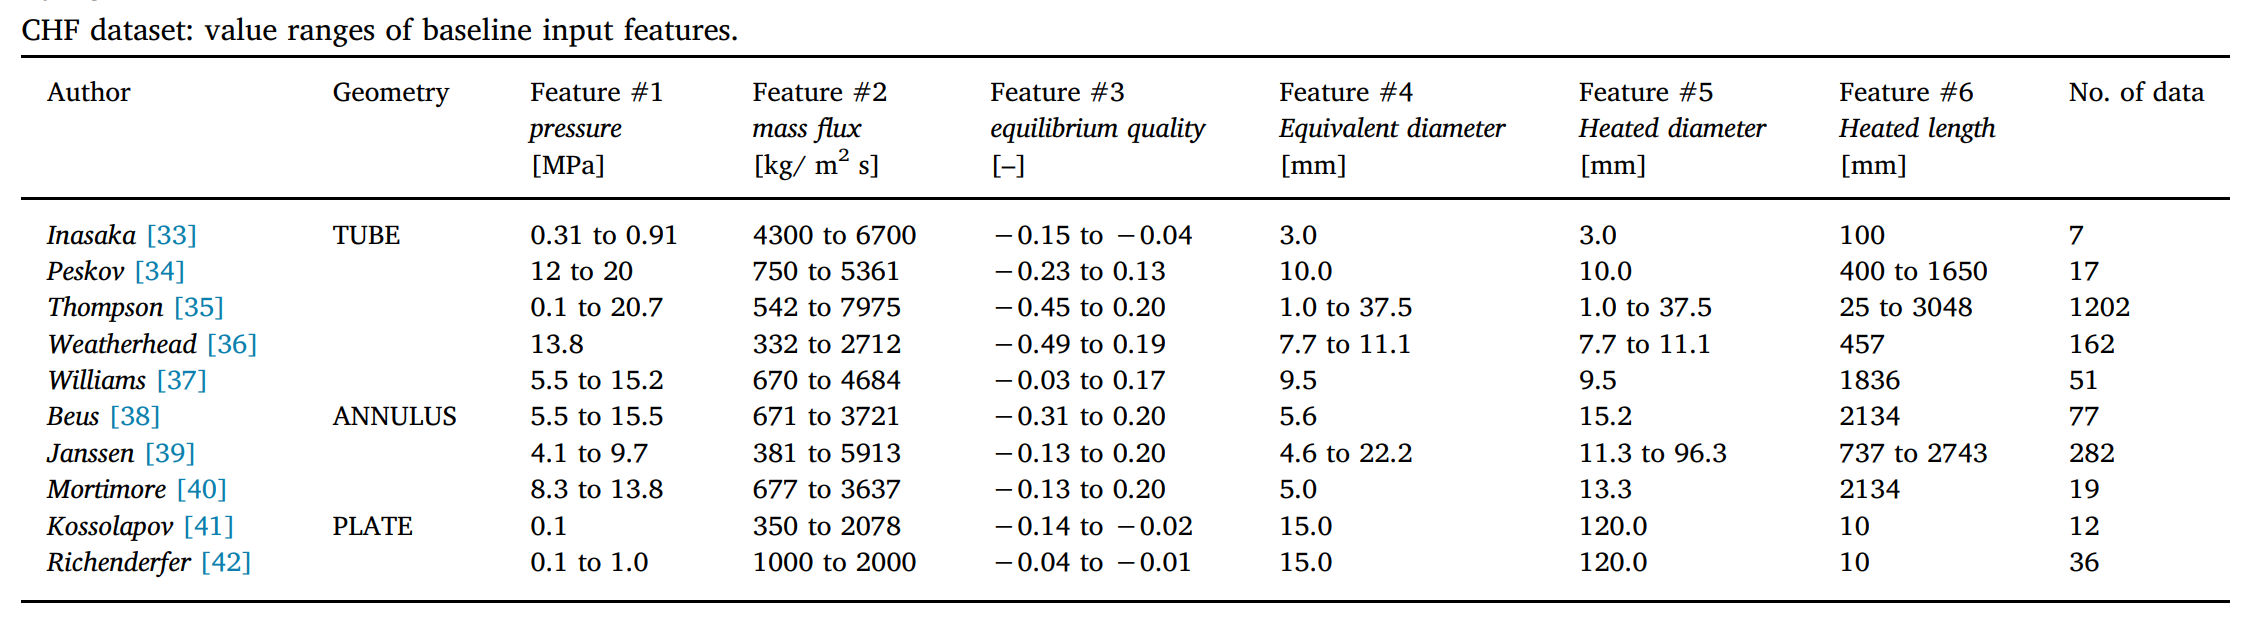

In [ ]:
missing_counts = train.isnull().sum(axis=1)
train['missing_count'] = train.isnull().sum(axis=1)
test['missing_count'] = test.isnull().sum(axis=1)-1

In [ ]:
cat_params={
            'depth': 7,
            'learning_rate': 0.1,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'max_bin': 200,
            'od_wait': 65,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'MultiClass',
            'loss_function': 'MultiClass',
}
def store_missing_rows(df, features):
    missing_rows = {}
    
    for feature in features:
        missing_rows[feature] = df[df[feature].isnull()]
    
    return missing_rows


def fill_missing_categorical(train,test,target, features, max_iterations=10):
    
    df=pd.concat([train.drop(columns=target),test.drop(columns=target)],axis="rows")
    df=df.reset_index(drop=True)
    
    # Step 1: Store the instances with missing values in each feature
    missing_rows = store_missing_rows(df, features)
    
    # Step 2: Initially fill all missing values with "Missing"
    for f in features:
        df[f]=df[f].fillna("Missing_"+f)
#     df[features] = df[features].fillna("Missing")
    
    for iteration in tqdm(range(max_iterations), desc="Iterations"):
        for feature in features:
            # Skip features with no missing values
            rows_miss = missing_rows[feature].index
            
            missing_temp = df.loc[rows_miss].copy()
            non_missing_temp = df.drop(index=rows_miss).copy()
            missing_temp = missing_temp.drop(columns=[feature])
            
            other_features = [x for x in features if x != feature]
            
            # Step 3: Use the remaining features to predict missing values using Random Forests
            X_train = non_missing_temp.drop(columns=[feature])
            y_train = non_missing_temp[[feature]]
            
            catboost_classifier = CatBoostClassifier(**cat_params)
            catboost_classifier.fit(X_train, y_train, cat_features=other_features, verbose=False)
            
            # Step 4: Predict missing values for the feature and update all N features
            y_pred = catboost_classifier.predict(missing_temp)
            df.loc[rows_miss, feature] = y_pred
    train[features] = np.array(df.iloc[:train.shape[0]][features])
    test[features] = np.array(df.iloc[train.shape[0]:][features])
    
    return train,test


train ,test= fill_missing_categorical(train,test,"equilibirum_quality",missing_cat,5)

# 4.1 Impute Numerical features

In [ ]:
missing_num=[f for f in train.columns if train[f].dtype!="O" and train[f].isna().sum()>0]
print(missing_num)

train_missing_pct = train[missing_num].isnull().mean() * 100
test_missing_pct = test[missing_num].isnull().mean() * 100

# Combine the missing percentages for train and test data into a single dataframe
missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])

# Print the missing percentage dataframe
print(missing_pct_df)

In [ ]:
cb_params = {
            'iterations': 500,
            'depth': 6,
            'learning_rate': 0.02,
            'l2_leaf_reg': 0.5,
            'random_strength': 0.2,
            'max_bin': 150,
            'od_wait': 80,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'IncToDec',
            'eval_metric': 'RMSE',
            'loss_function': 'RMSE',
            'random_state': 42,
        }
def rmse(y1,y2):
    return(np.sqrt(mean_squared_error(y1,y2)))

def fill_missing_numerical(train,test,target, features, max_iterations=10):
    
    df=pd.concat([train.drop(columns=target),test.drop(columns=target)],axis="rows")
    df=df.reset_index(drop=True)
    
    # Step 1: Store the instances with missing values in each feature
    missing_rows = store_missing_rows(df, features)
    
    # Step 2: Initially fill all missing values with "Missing"
    for f in features:
        df[f]=df[f].fillna(df[f].median())
    
    cat_features=[f for f in df.columns if df[f].dtype=="O"]
    dictionary = {feature: [] for feature in features}
    
    for iteration in tqdm(range(max_iterations), desc="Iterations"):
        for feature in features:
            # Skip features with no missing values
            rows_miss = missing_rows[feature].index
            
            missing_temp = df.loc[rows_miss].copy()
            non_missing_temp = df.drop(index=rows_miss).copy()
            y_pred_prev=missing_temp[feature]
            missing_temp = missing_temp.drop(columns=[feature])
            
            
            # Step 3: Use the remaining features to predict missing values using Random Forests
            X_train = non_missing_temp.drop(columns=[feature])
            y_train = non_missing_temp[[feature]]
            
            catboost_classifier = CatBoostRegressor(**cb_params)
            catboost_classifier.fit(X_train, y_train,cat_features=cat_features, verbose=False)
            
            # Step 4: Predict missing values for the feature and update all N features
            y_pred = catboost_classifier.predict(missing_temp)
            df.loc[rows_miss, feature] = y_pred
            error_minimize=rmse(y_pred,y_pred_prev)
            dictionary[feature].append(error_minimize)  # Append the error_minimize value

    for feature, values in dictionary.items():
        iterations = range(1, len(values) + 1)  # x-axis values (iterations)
        plt.plot(iterations, values, label=feature)  # plot the values
        plt.xlabel('Iterations')
        plt.ylabel('RMSE')
        plt.title('Minimization of RMSE with iterations')
        plt.legend()
        plt.show()
    train[features] = np.array(df.iloc[:train.shape[0]][features])
    test[features] = np.array(df.iloc[train.shape[0]:][features])

    return train,test


train,test = fill_missing_numerical(train,test,"equilibirum_quality",missing_num,20)

In [ ]:
train_missing_pct = train[missing_num+missing_cat].isnull().mean() * 100
test_missing_pct = test[missing_num+missing_cat].isnull().mean() * 100

# Combine the missing percentages for train and test data into a single dataframe
missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])

# Print the missing percentage dataframe
print(missing_pct_df)

In [ ]:
# threshold = 0
# print(train.shape)
# train = train[missing_counts <= threshold]
# train.shape
# train.reset_index(drop=True,inplace=True)

# 5. Feature Engineering

<font size="3">**Buckingham π theorem**</font>

<font size="3">The theorem states that if we have 'n' variables with 'k' fundamental dimensions, we can form 'n - k' dimensionless parameters.</font>

<font size="3">In this case, we have 6 variables: P (pressure), m (mass flux), d (equivalent diameter), h (heated diameter), l (heated length), and CHF (critical heat flux). These variables have 4 fundamental dimensions: [M] (mass), [L] (length), [T] (time), and [Θ] (temperature).</font>

<font size="3">To form a dimensionless parameter, we need to combine these variables in a way that eliminates the dimensions. Let's create a non-dimensional parameter as follows:</font>

<font size="3">Non-Dimensional Parameter: Π = (P * m) / (d * h * l * CHF)</font>

In [ ]:
train['non_dim']=train['pressure']*train['mass_flux']/(train['equivalent_diameter']*train["heated_diameter"]*train["length"]*train["chf_exp"])
test['non_dim']=test['pressure']*test['mass_flux']/(test['equivalent_diameter']*test["heated_diameter"]*test["length"]*test["chf_exp"])

# 5.1 Transformations

<font size="3">We're going to see what transformation works better for each feature and select them, the idea is to compress the data. There could be situations where you will have to stretch the data. These are the methods applied:</font>

1. <font size="3">**Log Transformation**</font>: <font size="3">This transformation involves taking the logarithm of each data point. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = log(x)

2. <font size="3">**Square Root Transformation**</font>: <font size="3">This transformation involves taking the square root of each data point. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = sqrt(x)

3. <font size="3">**Box-Cox Transformation**</font>: <font size="3">This transformation is a family of power transformations that includes the log and square root transformations as special cases. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = [(x^lambda) - 1] / lambda if lambda != 0
                y = log(x) if lambda = 0

4. <font size="3">**Yeo-Johnson Transformation**</font>: <font size="3">This transformation is similar to the Box-Cox transformation, but it can be applied to both positive and negative values. It is useful when the data is highly skewed and the variance increases with the mean.</font>
                y = [(|x|^lambda) - 1] / lambda if x >= 0, lambda != 0
                y = log(|x|) if x >= 0, lambda = 0
                y = -[(|x|^lambda) - 1] / lambda if x < 0, lambda != 2
                y = -log(|x|) if x < 0, lambda = 2

5. <font size="3">**Power Transformation**</font>: <font size="3">This transformation involves raising each data point to a power. It is useful when the data is highly skewed and the variance increases with the mean. The power can be any value, and is often determined using statistical methods such as the Box-Cox or Yeo-Johnson transformations.</font>
                y = [(x^lambda) - 1] / lambda if method = "box-cox" and lambda != 0
                y = log(x) if method = "box-cox" and lambda = 0
                y = [(x + 1)^lambda - 1] / lambda if method = "yeo-johnson" and x >= 0, lambda != 0
                y = log(x + 1) if method = "yeo-johnson" and x >= 0, lambda = 0
                y = [-(|x| + 1)^lambda - 1] / lambda if method = "yeo-johnson" and x < 0, lambda != 2
                y = -log(|x| + 1) if method = "yeo-johnson" and x < 0, lambda = 2

In [ ]:
cont_cols=[f for f in train.columns if train[f].dtype!='O' and f not in ["equilibirum_quality"] and train[f].nunique()>10]


sc=MinMaxScaler()
unimportant_features=[]
table = PrettyTable()
dt_params= {'min_samples_split': 80, 'min_samples_leaf': 30, 'max_depth': 8, 'criterion': 'absolute_error'}

table.field_names = ['Feature', 'Original RMSE(CV-TRAIN)', 'Transformed Feature', 'Tranformed RMSE(CV-TRAIN)']
for col in cont_cols:
    
#     # Log Transformation after MinMax Scaling(keeps data between 0 and 1)
#     train["log_"+col]=np.log1p(sc.fit_transform(train[[col]]))
#     test["log_"+col]=np.log1p(sc.transform(test[[col]]))
    
#     # Square Root Transformation
#     train["sqrt_"+col]=np.sqrt(sc.fit_transform(train[[col]]))
#     test["sqrt_"+col]=np.sqrt(sc.transform(test[[col]]))
    
    # Box-Cox transformation
    combined_data = pd.concat([train[[col]], test[[col]]], axis=0)
    transformer = PowerTransformer(method='box-cox')
    # Apply scaling and transformation on the combined data
    scaled_data = sc.fit_transform(combined_data)+1
    transformed_data = transformer.fit_transform(scaled_data)

    # Assign the transformed values back to train and test data
    train["bx_cx_" + col] = transformed_data[:train.shape[0]]
    test["bx_cx_" + col] = transformed_data[train.shape[0]:]
    
#     # Yeo-Johnson transformation
#     transformer = PowerTransformer(method='yeo-johnson')
#     train["y_J_"+col] = transformer.fit_transform(train[[col]])
#     test["y_J_"+col] = transformer.transform(test[[col]])
    
#     # Power transformation, 0.25
#     power_transform = lambda x: np.power(x + 1 - np.min(x), 0.25)
#     transformer = FunctionTransformer(power_transform)
#     train["pow_"+col] = transformer.fit_transform(sc.fit_transform(train[[col]]))
#     test["pow_"+col] = transformer.transform(sc.transform(test[[col]]))
    
#     # Power transformation, 0.1
#     power_transform = lambda x: np.power(x + 1 - np.min(x), 2)
#     transformer = FunctionTransformer(power_transform)
#     train["pow2_"+col] = transformer.fit_transform(sc.fit_transform(train[[col]]))
#     test["pow2_"+col] = transformer.transform(sc.transform(test[[col]]))
    
#     # log to power transformation
#     train["log_pow2"+col]=np.log1p(train["pow2_"+col])
#     test["log_pow2"+col]=np.log1p(test["pow2_"+col])
    
    temp_cols=["bx_cx_"+col,col ]
#     temp_cols=[col,"log_"+col,"sqrt_"+col, "bx_cx_"+col,"y_J_"+col ,"pow_"+col,"pow2_"+col,"log_pow2"+col ]

    
    # Fill na becaue, it would be Nan if the vaues are negative and a transformation applied on it
    train[temp_cols]=train[temp_cols].fillna(0)
    test[temp_cols]=test[temp_cols].fillna(0)

    #Apply PCA on  the features and compute an additional column
#     pca=TruncatedSVD(n_components=1)
#     x_pca_train=pca.fit_transform(train[temp_cols])
#     x_pca_test=pca.transform(test[temp_cols])
#     x_pca_train=pd.DataFrame(x_pca_train, columns=[col+"_pca_comb"])
#     x_pca_test=pd.DataFrame(x_pca_test, columns=[col+"_pca_comb"])
#     temp_cols.append(col+"_pca_comb")
#     #print(temp_cols)
#     test=test.reset_index(drop=True) # to combine with pca feature
    
#     train=pd.concat([train,x_pca_train],axis='columns')
#     test=pd.concat([test,x_pca_test],axis='columns')
    
    # See which transformation along with the original is giving you the best univariate fit with target
    kf=KFold(n_splits=5, shuffle=True, random_state=42)
    
    MAE=[]
    
    for f in temp_cols:
        X=train[[f]].values
        y=train["equilibirum_quality"].values
        
        mae=[]
        for train_idx, val_idx in kf.split(X,y):
            X_train,y_train=X[train_idx],y[train_idx]
            x_val,y_val=X[val_idx],y[val_idx]
            
            model=LinearRegression()
#             model=DecisionTreeRegressor(**dt_params)
            model.fit(X_train,y_train)
            y_pred=model.predict(x_val)
            mae.append(rmse(y_val,y_pred))
        MAE.append((f,np.mean(mae)))
        if f==col:
            orig_mae=np.mean(mae)
    best_col, best_acc=sorted(MAE, key=lambda x:x[1], reverse=False)[0]
    
    cols_to_drop = [f for f in temp_cols if  f!= best_col and f not in col]
#     print(cols_to_drop)
    final_selection=[f for f in temp_cols if f not in cols_to_drop]
    if cols_to_drop:
        unimportant_features=unimportant_features+cols_to_drop
#         train=train.drop(columns=cols_to_drop)
#         test=test.drop(columns=cols_to_drop)

    table.add_row([col,orig_mae,best_col ,best_acc])
print(table)    

<font size="3">**INSIGHTS:**</font>
1. <font size="3">I have applied log, sqrt, box-cox, yeo-johnson, power(0.25), power(2), log on all the aformentioned featrures followed by PCA on all the set of created features. In total, we have created 8 additional features for each original feature</font>
2. <font size="3">There is no great imporvement in the RMSE from original features and transformed feature</font>
3. <font size="3">I have not dropped the features, but saved them as unimportant set. These can be used in the later stage to extract some information</font>

# 5.2 Discrete Features- Encoding

<font size="3">For each categorical variable, perform the following encoding techniques:</font>
1. <font size="3">**Count/Frequency Encoding**</font>: <font size="3">Count the number of occurrences of each category and replace the category with its log count.</font>
2. <font size="3">**Count Labeling**</font>: <font size="3">Assign a label to each category based on its count, with higher counts receiving higher labels.</font>
3. <font size="3"> **Target-Guided Mean Encoding**</font>: <font size="3">Rank the categories based on the mean of target column across each category</font>

<font size="3"> Please note that the features a particular encoding technique is not selected only if it has superior technique and the correlation with that is high</font>

In [ ]:
train.nunique()

In [ ]:
discrete_cols=[f for f in train.columns if train[f].dtype=='O' ]
# Also adding a numerical column with 109 unique values
discrete_cols=discrete_cols+["chf_exp","missing_count"]
discrete_cols

In [ ]:
def OHE(train,test,cols,target):
    combined = pd.concat([train, test], axis=0)
    for col in cols:
        one_hot = pd.get_dummies(combined[col])
        counts = combined[col].value_counts()
        min_count_category = counts.idxmin()
        one_hot = one_hot.drop(min_count_category, axis=1)
        combined = pd.concat([combined, one_hot], axis="columns")
        combined = combined.drop(col, axis=1)
        combined = combined.loc[:, ~combined.columns.duplicated()]
    
    # split back to train and test dataframes
    train_ohe = combined[:len(train)]
    test_ohe = combined[len(train):]
    test_ohe.reset_index(inplace=True,drop=True)
    test_ohe.drop(columns=[target],inplace=True)
    
    return train_ohe, test_ohe

table = PrettyTable()
table.field_names = ['Feature', 'Encoded Features', 'RMSE']

for feature in discrete_cols:
    ## Target Guided Mean --Data Leakage Possible
    
    cat_labels=train.groupby([feature])['equilibirum_quality'].mean().sort_values().index
    cat_labels2={k:i for i,k in enumerate(cat_labels,0)}
    train[feature+"_target"]=train[feature].map(cat_labels2)
    test[feature+"_target"]=test[feature].map(cat_labels2)
    
    ## Count Encoding
    
    dic=train[feature].value_counts().to_dict()
    train[feature+"_count"]=np.log1p(train[feature].map(dic))
    test[feature+"_count"]=np.log1p(test[feature].map(dic))

    
    ## Count Labeling
    
    dic2=train[feature].value_counts().to_dict()
    list1=np.arange(len(dic2.values()),0,-1) # Higher rank for high count
    # list1=np.arange(len(dic2.values())) # Higher rank for low count
    dic3=dict(zip(list(dic2.keys()),list1))
    train[feature+"_count_label"]=train[feature].replace(dic3)
    test[feature+"_count_label"]=test[feature].replace(dic3)
    
    
    
    temp_cols=[feature+"_target", feature+"_count", feature+"_count_label"]
    if train[feature].dtype!="O":
        temp_cols.append(feature)
    else:
        train, test=OHE(train,test,[feature],"equilibirum_quality") # This will drop the col and does OHE
    
    # See which transformation along with the original is giving you the best univariate fit with target
    kf=KFold(n_splits=10, shuffle=True, random_state=42)
    
    MAE=[]
    
    for f in temp_cols:
        X=train[[f]].values
        y=train["equilibirum_quality"].values
        
        mae=[]
        for train_idx, val_idx in kf.split(X,y):
            X_train,y_train=X[train_idx],y[train_idx]
            x_val,y_val=X[val_idx],y[val_idx]
            
            model=LinearRegression()
            model.fit(X_train,y_train)
            y_pred=model.predict(x_val)
            mae.append(rmse(y_val,y_pred))
        MAE.append((f,np.mean(mae)))
    best_col, best_acc=sorted(MAE, key=lambda x:x[1], reverse=False)[0]
    
    # check correlation between best_col and other columns and drop if correlation >0.75
    corr = train[temp_cols].corr(method='pearson')
    corr_with_best_col = corr[best_col]
    cols_to_drop = [f for f in temp_cols if corr_with_best_col[f] > 0.3 and f != best_col]
    final_selection=[f for f in temp_cols if f not in cols_to_drop]
    if cols_to_drop:
        train = train.drop(columns=cols_to_drop)
        test = test.drop(columns=cols_to_drop)
    
    table.add_row([feature,final_selection,best_acc])
print(table)

# 5.3 Clustering-One Hot Transformation

<font size="3"> WE can take the less important transformed features and apply clustering followed by one-hot encoding on them</font>

In [ ]:
# table = PrettyTable()
# table.field_names = ['Cluster WOE Feature', 'RMSE(CV-TRAIN)']
# for col in cont_cols:
#     sub_set=[f for f in unimportant_features if col in f]
#     print(sub_set)
#     temp_train=train[sub_set]
#     temp_test=test[sub_set]
#     sc=StandardScaler()
#     temp_train=sc.fit_transform(temp_train)
#     temp_test=sc.transform(temp_test)
#     model = KMeans()


#     # Initialize the KElbowVisualizer with the KMeans model and desired range of clusters
#     visualizer = KElbowVisualizer(model, k=(3, 25), metric='calinski_harabasz', timings=False)

#     # Fit the visualizer to the data
#     visualizer.fit(np.array(temp_train))
#     plt.xlabel('Number of clusters (k)')
#     plt.ylabel('Calinski-Harabasz Index')
#     plt.show()

#     ideal_clusters = visualizer.elbow_value_

#     # print(ideal_clusters)
#     kmeans = KMeans(n_clusters=ideal_clusters)
#     kmeans.fit(np.array(temp_train))
#     labels_train = kmeans.labels_

#     train[col+'_OHE_cluster'] = labels_train
#     test[col+'_OHE_cluster'] = kmeans.predict(np.array(temp_test))
#     # Also, making a copy to do mean encoding followed by a log transformation
    
#     train[col+"_unimp_cluster_WOE"]=train[col+'_OHE_cluster']
#     test[col+"_unimp_cluster_WOE"]=test[col+'_OHE_cluster'] 
#     cat_labels=cat_labels=np.log1p(train.groupby([col+"_unimp_cluster_WOE"])['equilibirum_quality'].mean())
#     cat_labels2=cat_labels.to_dict()
#     train[col+"_unimp_cluster_WOE"]=train[col+"_unimp_cluster_WOE"].map(cat_labels2)
#     test[col+"_unimp_cluster_WOE"]=test[col+"_unimp_cluster_WOE"].map(cat_labels2)

#     X=train[[col+"_unimp_cluster_WOE"]].values
#     y=train["equilibirum_quality"].values

#     mae=[]
#     for train_idx, val_idx in kf.split(X,y):
#         X_train,y_train=X[train_idx],y[train_idx]
#         x_val,y_val=X[val_idx],y[val_idx]

#         model=LinearRegression()
#         model.fit(X_train,y_train)
#         y_pred=model.predict(x_val)
#         mae.append(rmse(y_val,y_pred))
#     table.add_row([col+"_unimp_cluster_WOE",np.mean(mae)])
    
#     train[col+'_OHE_cluster']=col+"_OHE_"+train[col+'_OHE_cluster'].astype(str)
#     test[col+'_OHE_cluster']=col+"_OHE_"+test[col+'_OHE_cluster'].astype(str)
#     train, test=OHE(train,test,[col+'_OHE_cluster'],"equilibirum_quality")
# print(table)

# 5.4 Feature Selection

In [ ]:
corr = train.corr()
plt.figure(figsize = (20, 20), dpi = 300)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask = mask, cmap = sns.diverging_palette(500, 10, as_cmap=True), annot = True, annot_kws = {'size' : 7})
plt.title('Correlation Matrix\n', fontsize = 25, weight = 'bold')
plt.show()

**Steps to Eliminate Correlated Fruit Features**:
1. <font size="3">Group features based on their parent feature. For example, all features derived from pressure come under one set</font>
2. <font size="3">Apply PCA on the set, Cluster-Target Encoding on the set</font>
3. <font size="3">See the performance of each feature on a cross-validated single feature-target model</font>
4. <font size="3">Select the feature with highest CV-RMSE</font>

In [ ]:
final_drop_list=[]

table = PrettyTable()
table.field_names = ['Original', 'Final Transformed feature', "RMSE(CV)- Regression"]

threshold=0.5
# It is possible that multiple parent features share same child features, so storing selected features to avoid selecting the same feature again
best_cols=[]

for col in cont_cols:
    sub_set=[f for f in train.columns if col in f and train[f].nunique()>100]
    # print(sub_set)
    
    correlated_features = []

    # Loop through each feature
    for i, feature in enumerate(sub_set):
        # Check correlation with all remaining features
        for j in range(i+1, len(sub_set)):
            correlation = np.abs(train[feature].corr(train[sub_set[j]]))
            # If correlation is greater than threshold, add to list of highly correlated features
            if correlation > threshold:
                correlated_features.append(sub_set[j])

    # Remove duplicate features from the list
    correlated_features = list(set(correlated_features))
    print(correlated_features)
    
#     if correlated_features: 

#         temp_train=train[correlated_features]
#         temp_test=test[correlated_features]
#         #Scale before applying PCA
#         sc=StandardScaler()
#         temp_train=sc.fit_transform(temp_train)
#         temp_test=sc.transform(temp_test)

#         # Initiate PCA
#         pca=TruncatedSVD(n_components=1)
#         x_pca_train=pca.fit_transform(temp_train)
#         x_pca_test=pca.transform(temp_test)
#         x_pca_train=pd.DataFrame(x_pca_train, columns=[col+"_pca_comb_final"])
#         x_pca_test=pd.DataFrame(x_pca_test, columns=[col+"_pca_comb_final"])
#         train=pd.concat([train,x_pca_train],axis='columns')
#         test=pd.concat([test,x_pca_test],axis='columns')

#         # Clustering
#         model = KMeans()


#         # Initialize the KElbowVisualizer with the KMeans model and desired range of clusters
#         visualizer = KElbowVisualizer(model, k=(5, 25), metric='calinski_harabasz', timings=False)

#         # Fit the visualizer to the data
#         visualizer.fit(np.array(temp_train))
#         plt.xlabel('Number of clusters (k)')
#         plt.ylabel('Calinski-Harabasz Index')
#         plt.title("Clustering on features from "+col)
#         plt.show()

#         ideal_clusters = visualizer.elbow_value_

#         if ideal_clusters is None:
#             ideal_clusters=5

#         # print(ideal_clusters)
#         kmeans = KMeans(n_clusters=ideal_clusters)
#         kmeans.fit(np.array(temp_train))
#         labels_train = kmeans.labels_

#         train[col+'_final_cluster'] = labels_train
#         test[col+'_final_cluster'] = kmeans.predict(np.array(temp_test))

#         cat_labels=cat_labels=np.log1p(train.groupby([col+"_final_cluster"])['equilibirum_quality'].mean())
#         cat_labels2=cat_labels.to_dict()
#         train[col+"_final_cluster"]=train[col+"_final_cluster"].map(cat_labels2)
#         test[col+"_final_cluster"]=test[col+"_final_cluster"].map(cat_labels2)

#         correlated_features=correlated_features+[col+"_pca_comb_final",col+"_final_cluster"]

#         # See which transformation along with the original is giving you the best univariate fit with target
#         kf=KFold(n_splits=5, shuffle=True, random_state=42)

#         MAE=[]

#         for f in correlated_features:
#             X=train[[f]].values
#             y=train["equilibirum_quality"].values

#             mae=[]
#             for train_idx, val_idx in kf.split(X,y):
#                 X_train,y_train=X[train_idx],y[train_idx]
#                 x_val,y_val=X[val_idx],y[val_idx]

#                 model=LinearRegression()
#     #             model=DecisionTreeRegressor(**dt_params)
#                 model.fit(X_train,y_train)
#                 y_pred=model.predict(x_val)
#                 mae.append(rmse(y_val,y_pred))
#             if f not in best_cols:
#                 MAE.append((f,np.mean(mae)))
#         best_col, best_acc=sorted(MAE, key=lambda x:x[1], reverse=False)[0]
#         best_cols.append(best_col)

#         cols_to_drop = [f for f in correlated_features if  f not in best_cols]
#         if cols_to_drop:
#             final_drop_list=final_drop_list+cols_to_drop
#         table.add_row([col,best_col ,best_acc])

# print(table)      

In [ ]:
final_drop_list=["bx_cx_pressure","geometry_count"]
final_drop_list=[f for f in final_drop_list if f not in cont_cols]
train.drop(columns=[*set(final_drop_list)],inplace=True)
test.drop(columns=[*set(final_drop_list)],inplace=True)

In [ ]:
train.shape,test.shape

<a id="5"></a>
# 5. Scaling the Data

In [ ]:
# feature_scale=[feature for feature in train.columns if feature not in ['equilibirum_quality']]

# scaler=StandardScaler()

# train[feature_scale]=scaler.fit_transform(train[feature_scale])
# test[feature_scale]=scaler.transform(test[feature_scale])

X_train=train.drop(['equilibirum_quality'],axis=1)
y_train=train['equilibirum_quality']

X_test=test.copy()

print(X_train.shape,X_test.shape)

# 7. Modeling

<font size="3">Kudos to [tetsutani](http://www.kaggle.com/code/tetsutani/ps3e11-eda-xgb-lgbm-cat-ensemble-lb-0-29267) for a great modeling framework</font>

In [ ]:
class Splitter:
    def __init__(self, test_size=0.2, kfold=True, n_splits=5):
        self.test_size = test_size
        self.kfold = kfold
        self.n_splits = n_splits

    def split_data(self, X, y, random_state_list):
        if self.kfold:
            for random_state in random_state_list:
                kf = KFold(n_splits=self.n_splits, random_state=random_state, shuffle=True)
                for train_index, val_index in kf.split(X, y):
                    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
                    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
                    yield X_train, X_val, y_train, y_val
        else:
            for random_state in random_state_list:
                X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=self.test_size, random_state=random_state)
                yield X_train, X_val, y_train, y_val

class Regressor:
    def __init__(self, n_estimators=100, device="gpu", random_state=0):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.reg_models = self._define_reg_model()
        self.len_models = len(self.reg_models)
        
    def _define_reg_model(self):
        
        xgb_params = {
            'n_estimators': self.n_estimators,
            'max_depth': 6,
            'learning_rate': 0.0116,
            'colsample_bytree': 1,
            'subsample': 0.6085,
            'min_child_weight': 9,
            'reg_lambda': 4.879e-07,
            'max_bin': 431,
            #'booster': 'dart',
            'n_jobs': -1,
            'eval_metric': 'rmse',
            'objective': "reg:squarederror",
            #'tree_method': 'hist',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        if self.device == 'gpu':
            xgb_params['tree_method'] = 'gpu_hist'
            xgb_params['predictor'] = 'gpu_predictor'

        xgb_params2 = {
            'n_estimators': self.n_estimators,
            'max_depth': 7,
            'learning_rate': 0.049,
            'colsample_bytree': 0.5,
            'subsample': 0.7,
            'min_child_weight': 9,
            'reg_lambda': 4.879e-07,
            'max_bin': 431,
            #'booster': 'dart',
            'n_jobs': -1,
            'eval_metric': 'rmse',
            'objective': "reg:squarederror",
            'tree_method': 'approx',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        lgb_params = {
            'n_estimators': self.n_estimators,
            'max_depth': 8,
            "num_leaves": 16,
            'learning_rate': 0.05,
            'subsample': 0.7,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.25,
            'reg_lambda': 5e-07,
            'objective': 'regression_l2',
            'metric': 'mean_squared_error',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state
        }
        lgb_params2 = {
            'n_estimators': self.n_estimators,
            'max_depth': 10,
            "num_leaves": 16,
            'learning_rate': 0.019000000000000003,
            'subsample': 0.3,
            'colsample_bytree': 0.5,
            'reg_alpha': 0.280490490266035,
            'reg_lambda':0.8609215326333549,
            'objective': 'regression_l2',
            'metric': 'mean_squared_error',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state
        }
        
        cb_params = {
            'iterations': self.n_estimators,
            'depth': 6,
            'learning_rate': 0.02,
            'l2_leaf_reg': 0.5,
            'random_strength': 0.2,
            'max_bin': 150,
            'od_wait': 80,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'IncToDec',
            'eval_metric': 'RMSE',
            'loss_function': 'RMSE',
            'task_type': self.device.upper(),
            'random_state': self.random_state
        }
        
        cb_params2 = {
            'iterations': self.n_estimators,
            'depth': 8,
            'learning_rate': 0.02,
            'l2_leaf_reg': 0.9000000000000002,
            'random_strength': 0.1,
            'max_bin': 150,
            'od_wait': 90,
            'one_hot_max_size': 65,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'IncToDec',
            'eval_metric': 'RMSE',
            'loss_function': 'RMSE',
            'task_type': self.device.upper(),
            'random_state': self.random_state
        }
        
        cb_sym_params = cb_params.copy()
        cb_sym_params['grow_policy'] = 'SymmetricTree'
        cb_loss_params = cb_params.copy()
        cb_loss_params['grow_policy'] = 'Lossguide'
    
      
        cb_loss_params={
            'iterations': self.n_estimators,
            'depth': 8,
            'learning_rate': 0.01,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'max_bin': 200,
            'od_wait': 65,
            'one_hot_max_size': 70,
            'grow_policy': 'Lossguide',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'RMSE',
            'loss_function': 'RMSE',
            'task_type': self.device.upper(),
            'random_state': self.random_state
        }
        dt_params= {'min_samples_split': 70, 'min_samples_leaf': 45, 'max_depth': 14, 'criterion': 'squared_error'}
        knn_params= {'weights': 'uniform', 'p': 1, 'n_neighbors': 12, 'leaf_size': 20, 'algorithm': 'kd_tree'}
        hist_params={'l2_regularization': 0.171778774949396,
            'early_stopping': True,
            'learning_rate': 0.005,
            "loss":"squared_error",
            'max_iter': self.n_estimators,
            'n_iter_no_change': 400,
            'max_depth': 29,
            'max_bins': 255,
            'min_samples_leaf': 33,
            'max_leaf_nodes':41,
            'random_state': self.random_state,}

        reg_models = {
            'xgb_reg': xgb.XGBRegressor(**xgb_params),
            'xgb_reg2': xgb.XGBRegressor(**xgb_params2),

            'lgb_reg2': lgb.LGBMRegressor(**lgb_params),
            'lgb_reg': lgb.LGBMRegressor(**lgb_params2),
#             "hgbm": HistGradientBoostingRegressor(**hist_params),
            "hgbm": HistGradientBoostingRegressor(max_iter=self.n_estimators, learning_rate=0.05, 
                                                  loss="squared_error",  n_iter_no_change=400,random_state=self.random_state),
            'cat_reg': CatBoostRegressor(**cb_params),
            'cat_reg2': CatBoostRegressor(**cb_params2),
            "cat_sym": CatBoostRegressor(**cb_sym_params),
            "cat_loss": CatBoostRegressor(**cb_loss_params),
            'etr': ExtraTreesRegressor(min_samples_split=30, min_samples_leaf= 5, max_depth=14,
                                       n_estimators=200,random_state=self.random_state),
            "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=500,max_depth= 5, learning_rate= 0.127,loss="squared_error", random_state=self.random_state),
#             "RandomForestRegressor": RandomForestRegressor(max_depth= 14,max_features= 'auto',min_samples_split= 30,
#                                                            min_samples_leaf= 15,  n_estimators=500, random_state=self.random_state, n_jobs=-1),
            "RandomForestRegressor": RandomForestRegressor(max_depth= 12,max_features= 'auto',min_samples_split= 30,
                                                           min_samples_leaf= 5,  n_estimators=500, random_state=self.random_state, n_jobs=-1),
            'dt': DecisionTreeRegressor(**dt_params),
            
#             "lr":LinearRegression(),
#             "knn":KNeighborsRegressor(**knn_params),
#             "PassiveAggressiveRegressor": PassiveAggressiveRegressor(max_iter=3000, tol=1e-3, n_iter_no_change=30, random_state=self.random_state),
#             "HuberRegressor": HuberRegressor(max_iter=3000),
            
        }


        return reg_models

## 7.2 Weighted Ensembling

In [ ]:
class OptunaWeights:
    def __init__(self, random_state):
        self.study = None
        self.weights = None
        self.random_state = random_state

    def _objective(self, trial, y_true, y_preds):
        # Define the weights for the predictions from each model
        weights = [trial.suggest_float(f"weight{n}", 0, 1) for n in range(len(y_preds))]

        # Calculate the weighted prediction
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=weights)

        # Calculate the MAE score for the weighted prediction
        score = rmse(y_true, weighted_pred)
        return score

    def fit(self, y_true, y_preds, n_trials=1000):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        self.study = optuna.create_study(sampler=sampler, study_name="OptunaWeights", direction='minimize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=n_trials)
        self.weights = [self.study.best_params[f"weight{n}"] for n in range(len(y_preds))]

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error, must be fitted before predict'
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=self.weights)
        return weighted_pred

    def fit_predict(self, y_true, y_preds, n_trials=1000):
        self.fit(y_true, y_preds, n_trials=n_trials)
        return self.predict(y_preds)
    
    def weights(self):
        return self.weights

In [ ]:
kfold = True
n_splits = 1 if not kfold else 10
random_state = 42
random_state_list = [42] 
n_estimators = 9999 
early_stopping_rounds = 200
verbose = False
device = 'cpu'

splitter = Splitter(kfold=kfold, n_splits=n_splits)


# Initialize an array for storing test predictions
test_predss = np.zeros(X_test.shape[0])
ensemble_score = []
weights = []
trained_models = dict(zip(Regressor().reg_models.keys(), [[] for _ in range(Regressor().len_models)]))
trained_models = {'lgb_reg':[], 'cat_reg':[],'xgb_reg':[]}

# Evaluate on validation data and store predictions on test data
for i, (X_train_, X_val, y_train_, y_val) in enumerate(splitter.split_data(X_train, y_train, random_state_list=random_state_list)):
    n = i % n_splits
    m = i // n_splits

    # Get a set of Regressor models
    reg = Regressor(n_estimators, device, random_state)
    models = reg.reg_models

    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []

    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        if ('cat' in name) or ("lgb" in name) or ("xgb" in name):
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name=='hgbm':
            model.fit(X_train_, y_train_)
        elif name=='ann':
            model.fit(X_train_, y_train_, validation_data=(X_val, y_val),batch_size=2, epochs=60,verbose=verbose)
        else:
            model.fit(X_train_, y_train_)
        if name=="ann":
            y_val_pred = model.predict(X_val)[:,0]
            test_pred = model.predict(X_test)[:,0]
        else:
            y_val_pred = model.predict(X_val)
            test_pred = model.predict(X_test)


        score = rmse(y_val, y_val_pred)
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] RMSE score: {score:.5f}')

        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
        if name in trained_models.keys():
            trained_models[f'{name}'].append(deepcopy(model))

    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state)
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)
    score = rmse(y_val, y_val_pred)
    print(f'Ensemble [FOLD-{n} SEED-{random_state_list[m]}] RMSE score {score:.5f}')
    ensemble_score.append(score)
    weights.append(optweights.weights)
    test_predss += optweights.predict(test_preds) / (n_splits * len(random_state_list))

    gc.collect()

In [ ]:
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Ensemble RMSE score {mean_score:.5f} ± {std_score:.5f}')

# Print the mean and standard deviation of the ensemble weights for each model
print('--- Model Weights ---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name} {mean_weight:.5f} ± {std_weight:.5f}')

## 7.3 Feature importance Visualization (XGBoost, LightGBM, Catboost)

In [ ]:
def visualize_importance(models, feature_cols, title, top=40):
    importances = []
    feature_importance = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df["importance"] = model.feature_importances_
        _df["feature"] = pd.Series(feature_cols)
        _df["fold"] = i
        _df = _df.sort_values('importance', ascending=False)
        _df = _df.head(top)
        feature_importance = pd.concat([feature_importance, _df], axis=0, ignore_index=True)
        
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    # display(feature_importance.groupby(["feature"]).mean().reset_index().drop('fold', axis=1))
    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=feature_importance, color='crimson', errorbar='sd')
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.title(f'{title} Feature Importance [Top {top}]', fontsize=18)
    plt.grid(True, axis='x')
    plt.show()
    
for name, models in trained_models.items():
    visualize_importance(models, list(X_train.columns), name)

## 7.4 Results

In [ ]:
sub = pd.read_csv('/kaggle/input/playground-series-s3e15/sample_submission.csv')
sub['x_e_out [-]'] = test_predss
sub.to_csv('submission.csv',index=False)
sub